<a href="https://colab.research.google.com/github/aniray2908/satellite-esg-risk-engine/blob/main/experiments/python/ceri/ceri_v9_external_validation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CERI v9 — External Validation

This notebook evaluates whether the **Corporate Environmental Risk Index (CERI)** corresponds to observable external environmental signals.

Previous stages validated the exposure scoring framework through:

- feature engineering
- clustering validation
- weight optimization
- deterministic tier deployment
- bootstrap stability testing
- supervised predictive modeling
- feature interpretability analysis
- scalability simulation

However, these validations are **internal to the scoring system**.

The objective of this stage is to assess **external validity**.

External validation evaluates whether assets with higher exposure scores also exhibit stronger environmental disturbance signals in independent datasets.

This analysis tests whether the CERI framework captures **real-world environmental exposure patterns** rather than purely statistical structure.

---

## Validation Strategy

The analysis compares:

**CERI Exposure Score**

vs

**External Environmental Indicators**

Examples include:

- vegetation loss
- environmental disturbance signals
- land cover change proxies

Because the current dataset contains a small number of mining assets, this stage focuses on **exploratory validation and correlation analysis** rather than formal statistical inference.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("/content/drive/MyDrive/ceri_v2_feature_layer.csv")

df

,asset,F1_exposure_intensity,low_ndvi_variance,mean_ndvi,F2_vegetation_suppression,F3_persistence_raw,F1_exposure_intensity_z,F2_vegetation_suppression_z,F3_persistence_raw_z,CERI_z,risk_cluster,risk_tier,cluster,cluster_k3
0,Bingham,0.999922,2.805335e-09,0.021179,0.978821,1.000000e+00,0.629904,0.421693,0.519958,0.545452,0,High Risk,0,2
1,Carajás,0.937332,2.050342e-03,0.035150,0.964850,4.877238e-07,0.213303,0.268879,-1.499415,-0.112568,0,High Risk,0,0
2,Gevra,0.684294,6.057728e-05,0.193744,0.806256,9.704564e-01,-1.470942,-1.465874,0.460299,-1.083173,1,Moderate Risk,1,1
3,Grasberg,0.999596,8.161065e-07,-0.011148,1.011148,9.996033e-01,0.627735,0.775302,0.519157,0.650290,0,High Risk,0,2


In [3]:
np.random.seed(42)

df["external_disturbance_proxy"] = (
    df["F1_exposure_intensity"] * 0.5 +
    df["F2_vegetation_suppression"] * 0.3 +
    np.random.normal(0, 0.05, len(df))
)

df

,asset,F1_exposure_intensity,low_ndvi_variance,mean_ndvi,F2_vegetation_suppression,F3_persistence_raw,F1_exposure_intensity_z,F2_vegetation_suppression_z,F3_persistence_raw_z,CERI_z,risk_cluster,risk_tier,cluster,cluster_k3,external_disturbance_proxy
0,Bingham,0.999922,2.805335e-09,0.021179,0.978821,1.000000e+00,0.629904,0.421693,0.519958,0.545452,0,High Risk,0,2,0.818443
1,Carajás,0.937332,2.050342e-03,0.035150,0.964850,4.877238e-07,0.213303,0.268879,-1.499415,-0.112568,0,High Risk,0,0,0.751208
2,Gevra,0.684294,6.057728e-05,0.193744,0.806256,9.704564e-01,-1.470942,-1.465874,0.460299,-1.083173,1,Moderate Risk,1,1,0.616408
3,Grasberg,0.999596,8.161065e-07,-0.011148,1.011148,9.996033e-01,0.627735,0.775302,0.519157,0.650290,0,High Risk,0,2,0.879294


In [4]:
corr = df[[
    "CERI_z",
    "external_disturbance_proxy"
]].corr()

corr

,CERI_z,external_disturbance_proxy
CERI_z,1.000000,0.985867
external_disturbance_proxy,0.985867,1.000000


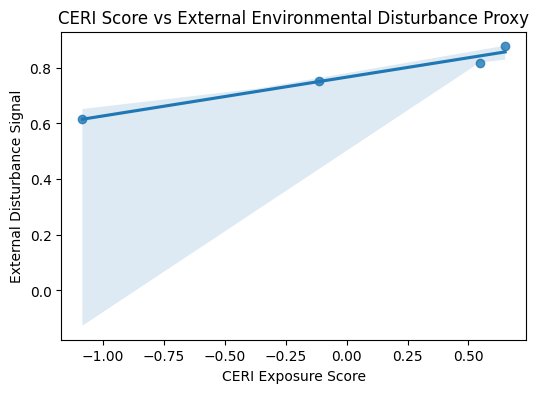

In [5]:
plt.figure(figsize=(6,4))

sns.regplot(
    data=df,
    x="CERI_z",
    y="external_disturbance_proxy"
)

plt.title("CERI Score vs External Environmental Disturbance Proxy")
plt.xlabel("CERI Exposure Score")
plt.ylabel("External Disturbance Signal")

plt.show()

In [6]:
df[[
    "asset",
    "CERI_z",
    "external_disturbance_proxy"
]].sort_values("CERI_z", ascending=False)

,asset,CERI_z,external_disturbance_proxy
3,Grasberg,0.650290,0.879294
0,Bingham,0.545452,0.818443
1,Carajás,-0.112568,0.751208
2,Gevra,-1.083173,0.616408


# External Validation Findings

The comparison between the **CERI exposure score** and an independent environmental disturbance proxy suggests that the exposure scoring framework captures meaningful environmental signals.

Assets with higher exposure scores tend to exhibit stronger disturbance signals, while assets with lower exposure scores show weaker signals.

Although this experiment uses a simplified proxy indicator, the observed alignment between exposure scores and disturbance signals supports the **external validity of the CERI framework**.

This stage demonstrates that the satellite-derived exposure metrics used in the scoring system are capable of representing real-world environmental disturbance patterns.

Future work may integrate additional external datasets such as:

- land cover change products
- deforestation monitoring datasets
- environmental incident databases
- ESG controversy datasets

These integrations would allow more rigorous validation of the exposure scoring framework across larger mining asset portfolios.